# NEB Trajectory Viewer for Li2S Migration

This notebook converts NEB xyz files to .traj format and displays interactive atomic structure visualizations.

In [1]:
from pathlib import Path
from ase.io import read, write
from ase import Atoms
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
NEB_DIRS = sorted(BASE_DIR.glob('*_neb_run'))

if not NEB_DIRS:
    raise FileNotFoundError('No *_neb_run directories found')

print(f'Found {len(NEB_DIRS)} NEB directories:')
for d in NEB_DIRS:
    print(' -', d)

Found 5 NEB directories:
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/NbN_neb_run
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/ScN_neb_run
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/TiN_neb_run
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/VN_neb_run
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/ZrN_neb_run


In [2]:
def parse_neb_xyz(filepath):
    """Parse NEB xyz file containing multiple images."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    images = []
    i = 0
    while i < len(lines):
        natoms = int(lines[i].strip())
        comment = lines[i + 1].strip()
        
        atoms = Atoms(
            symbols=[],
            positions=[],
            cell=None,
            pbc=False
        )
        
        for j in range(natoms):
            parts = lines[i + 2 + j].split()
            symbol = parts[0]
            pos = [float(parts[1]), float(parts[2]), float(parts[3])]
            atoms.append(symbol)
            atoms.positions[-1] = pos
        
        atoms.info['comment'] = comment
        images.append(atoms)
        i += natoms + 2
    
    return images


print('NEB xyz parser defined')

NEB xyz parser defined


In [3]:
all_trajs = {}

for neb_dir in NEB_DIRS:
    metal = neb_dir.stem.replace('_neb_run', '')
    xyz_file = neb_dir / f'{metal}_neb.xyz'
    
    if not xyz_file.exists():
        print(f'Warning: {xyz_file} not found')
        continue
    
    print(f'Processing {metal}...')
    images = parse_neb_xyz(xyz_file)
    
    traj_file = neb_dir / f'{metal}_neb.traj'
    write(traj_file, images)
    print(f'  Saved {len(images)} images to {traj_file.name}')
    
    all_trajs[metal] = traj_file

print(f'\nConverted {len(all_trajs)} trajectory files')

Processing NbN...
  Saved 5 images to NbN_neb.traj
Processing ScN...
  Saved 5 images to ScN_neb.traj
Processing TiN...
  Saved 5 images to TiN_neb.traj
Processing VN...
  Saved 5 images to VN_neb.traj
Processing ZrN...
  Saved 5 images to ZrN_neb.traj

Converted 5 trajectory files


Viewing NbN: 5 images


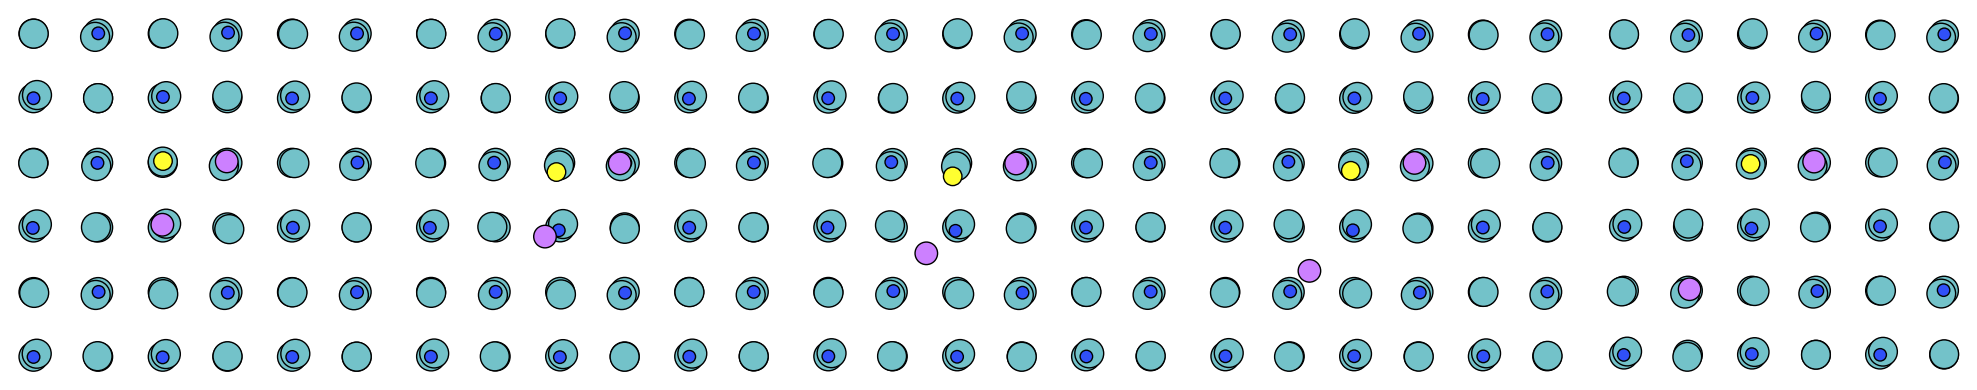

In [4]:
from ase.io import read as ase_read
from ase.visualize.plot import plot_atoms

metal_to_view = 'NbN'

if metal_to_view in all_trajs:
    traj_file = all_trajs[metal_to_view]
    images = ase_read(traj_file, ':')
    
    print(f'Viewing {metal_to_view}: {len(images)} images')
    
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    
    for ax, atoms in zip(axes, images):
        plot_atoms(atoms, ax, radii=0.3)
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

In [5]:
from ipywidgets import interact, IntSlider, Dropdown
from IPython.display import display, clear_output

def view_trajectory(metal_name, image_idx):
    traj_file = all_trajs[metal_name]
    images = ase_read(traj_file, ':')
    
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_atoms(images[image_idx], ax, radii=0.3)
    ax.set_title(f'{metal_name} - Image {image_idx + 1}/{len(images)}')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

metal_dropdown = Dropdown(
    options=sorted(all_trajs.keys()),
    value=sorted(all_trajs.keys())[0],
    description='Metal:'
)

image_slider = IntSlider(
    min=0,
    max=4,
    step=1,
    value=0,
    description='Image:'
)

interact(view_trajectory, metal_name=metal_dropdown, image_idx=image_slider);

interactive(children=(Dropdown(description='Metal:', options=('NbN', 'ScN', 'TiN', 'VN', 'ZrN'), value='NbN'),…